In [1]:
import sys
from sklearn.exceptions import InconsistentVersionWarning
import os.path
import numpy as np
from cVAE import cVAE
from MDN import mdn, Mixture
from tortreinador.utils.View import init_bias, split_weights, init_weights
import torch
import joblib
from config import PlanetsDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
import math
import warnings
import seaborn as sns
from matplotlib import ticker
from matplotlib.ticker import AutoMinorLocator
import json
from scipy.stats import gaussian_kde

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
def plot(s_i, o_p, mcmc, model_name='MDN', save_path=None, planet_name='Unknown'):
    x_labels = [
        'WRF',
        'MRF',
        'CRF',
        'WMF',
        'CMF',
        '$P_{\mathrm{CMB}}$(TPa)',
        '$T_{\mathrm{CMB}}(10^{3}$K$)$',
        '$k_{2}$'
    ]
    x_locator = [0.05, 0.2, 0.2, 0.02, 0.2, 0.5, 2, 0.5]
    x_max = [0.15, 1, 1, 0.1, 1, 1.5, 6, 1.5]
    # xminorlocators = [0.01, 0.04, 0.04, 0.004, 0.04, 0.08, 0.2, 0.04]
    colors = ["steelblue"] * len(output_parameters)

    fig, axs = plt.subplots(2, 4, figsize=(16, 8))
    axs = axs.flatten()
    for param in range(len(o_p)):
        ax = axs[param]
        # plot MCMC results
        x = mcmc[:, param]
        ax.hist(x, density=True, bins=15, histtype='step', color='#4682b4', linewidth=2, label='MCMC inference')
        median = np.median(x)
        ax.axvline(median, color='#4682b4', linestyle='--', lw=2)

        # plot MDN results
        params_x = s_i[:, param]
        counts, bins, _ = ax.hist(params_x, density=True, bins=15, histtype='step', color='red', linewidth=2,
                                  label='{} inference'.format(model_name))
        median = np.median(params_x)
        ax.axvline(median, color='r', linestyle='--', lw=2)

        # Set x-axis label from the provided list
        ax.set_xlabel(x_labels[param], fontsize=16)
        ax.tick_params(axis='both', labelsize=14)

        ax.set_xlim(0, x_max[param])
        ax.set_yticks([])
        ax.xaxis.set_major_locator(plt.MultipleLocator(x_locator[param]))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

        # Add legend to the first subplot
        if param == 0:
            ax.legend()

    # Adjust the layout
    plt.tight_layout()

    # Display the plot
    plt.show()

def process_after_pred(pred_inverse, pred_inverse_2, mcmc):
    
    pred_inverse[:, 5] = pred_inverse[:, 5] / 1000
    pred_inverse[:, 6] = pred_inverse[:, 6] / 1000
    
    pred_inverse_2[:, 5] = pred_inverse_2[:, 5] / 1000
    pred_inverse_2[:, 6] = pred_inverse_2[:, 6] / 1000
    
    mcmc['CPS'] = mcmc['CPS'] / 1000
    mcmc['CTP'] = mcmc['CTP'] / 1000
    
    # mdn_inverse[:, 5] = mdn_inverse[:, 5] / 1000
    # mdn_inverse[:, 6] = mdn_inverse[:, 6] / 1000
    
    # no_lower_zero_mask = np.all(pred_inverse > 0, axis=1)
    # pred_inverse = pred_inverse[no_lower_zero_mask]
    # 
    # no_lower_zero_mask_2 = np.all(pred_inverse_2 > 0, axis=1)
    # pred_inverse_2 = pred_inverse_2[no_lower_zero_mask_2]
    # 
    # no_upper_one_mask = np.sum(pred_inverse[:, [0, 1, 2]], axis=1) <= 1
    # pred_inverse = pred_inverse[no_upper_one_mask]
    # 
    # no_upper_one_mask_2 = np.sum(pred_inverse_2[:, [0, 1, 2]], axis=1) <= 1
    # pred_inverse_2 = pred_inverse_2[no_upper_one_mask_2]
    
    return pred_inverse, pred_inverse_2, mcmc

def sampling_from_gmm_pdf(gmm, y_l_):
    bins = np.concatenate(([y_l_[0, 0]], y_l_[:, 0]))
    d_x = {param: [] for param in output_parameters}
    # density_y = {param: [] for param in output_parameters}
    
    # Loop start here
    for out_param in range(len(output_parameters)):
        GMM_PDF_Tor_sub = gmm[:, :, out_param]
    
        GMM_PDF_Tor_sub_sum = GMM_PDF_Tor_sub.sum(axis=1)[:, np.newaxis]
    
        prob = np.divide(GMM_PDF_Tor_sub, GMM_PDF_Tor_sub_sum)
        non_zero = np.count_nonzero(GMM_PDF_Tor_sub, axis=1)
    
        cond = np.where(GMM_PDF_Tor_sub_sum == 0, True, False)
        p = np.where(cond, 1 / len(y_l_), prob)
        size_cond = np.where((non_zero < 20) & (non_zero > 0), non_zero, np.where(non_zero == 0, 20, 20))
    
        idx = [np.random.choice(y_l_[:, 0], size=size_cond[i], replace=cond[i, 0], p=p[i, :]) for i in range(len(GMM_PDF_Tor_sub))]
        indices = [np.searchsorted(bins, idx[i]) - 1 for i in range(len(idx))]
        flattened_indices = np.concatenate(indices)
        d_x[output_parameters[out_param]] = np.concatenate([d_x[output_parameters[out_param]], y_l_[:, 0][flattened_indices].ravel()])
    
    return d_x

def calculate_GMM(p, m, s, y_label):
    """
    Calculate the probability density function of the Gaussian Mixture Model

        Args:
            - param p: pi
            - param m: mean
            - param s: standard deviation
            - param y_label: e.g. np.arange(0, 1, 0.001)

    """
    if len(y_label.shape) == 1:
        y_label = y_label.reshape(-1, 1)

    y_label_ = y_label[:, np.newaxis, np.newaxis, :]

    mu_sub_T = np.transpose(m, (0, 2, 1))
    sigma_sub_T = np.transpose(s, (0, 2, 1))

    exponent = np.exp(
        -1 / 2 * np.square(np.transpose((y_label_ - mu_sub_T), (1, 2, 0, 3)) / sigma_sub_T[:, :, np.newaxis, :]))
    factors = 1 / math.sqrt(2 * math.pi) / sigma_sub_T[:, :, np.newaxis, :]

    # Shape (number of data, number of y_label, types) e.g.(1000, 10, 8)
    GMM_PDF = np.sum(p[:, np.newaxis, np.newaxis, :] * factors * exponent, axis=-1).transpose((0, -1, 1))
    # GMM_PDF = GMM_PDF.reshape(GMM_PDF.shape[0] * GMM_PDF.shape[1], GMM_PDF.shape[-1]).transpose((-1, 0))
    # f = e.transpose((-1, 0))
    return GMM_PDF

input_parameters = [
    'Mass',
    'Radius',
    'FeMg',
    'SiMg'
]

output_parameters = [
    'WRF',
    'MRF',
    'CRF',
    'WMF',
    'CMF',
    'CPS',
    'CTP',
    'k2'
]

x_labels = [
    'WRF',
    'MRF',
    'CRF',
    'WMF',
    'CMF',
    '$P_{\mathrm{CMB}}$(TPa)',
    '$T_{\mathrm{CMB}}(10^{3}$K$)$',
    '$k_{2}$'
]

x_locator = [0.05, 0.2, 0.2, 0.02, 0.2, 0.5, 2, 0.5]
x_max = [0.15, 1, 1, 0.1, 1, 1.5, 6, 1.5]
xminorlocators = [0.01, 0.04, 0.04, 0.004, 0.04, 0.08, 0.2, 0.04]
planet_name = ['Kepler78b', 'Earth']
TIMES = 20
DEVICE = 'cuda'
y_l = np.arange(0, 1, 0.001).reshape(-1, 1)


# Configuration

In [3]:
device = 'cuda'
base_path = '.\\data'
heatmap_save_path = os.path.join(base_path, 'Charts', 'heatmap')
cvae_path = os.path.join(base_path, 'cVAE', '50th')
mdn_path = os.path.join(base_path, 'MDN', '50th')

degree_50 = os.path.join(base_path, '50th')
x_scaler_cvae = joblib.load(os.path.join(degree_50, 'scaler_x.save'))
y_scaler_cvae = joblib.load(os.path.join(degree_50, 'scaler_y.save'))

degree_50_mdn = os.path.join(base_path, '50th')
x_scaler_mdn = joblib.load(os.path.join(degree_50_mdn, 'scaler_x.save'))
y_scaler_mdn = joblib.load(os.path.join(degree_50_mdn, 'scaler_y.save'))

# cVAE
cvae = cVAE(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024, c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae)
cvae.load_state_dict(torch.load(os.path.join(cvae_path, "best_model.pth")))
model = cvae.decoder
model.to(DEVICE)

# MDN
mdn_model = mdn(input_size=len(input_parameters), output_size=len(output_parameters), num_hidden=512, num_gaussian=10)
init_weights(mdn_model)
mdn_model.load_state_dict(torch.load(os.path.join(mdn_path, "best_model.pth")))
mix = Mixture()
mdn_model.to(DEVICE)

# generator = PlanetsDataGenerator(size=1000)
generator = PlanetsDataGenerator(size=1000)

In [4]:
N_z = 20
model.eval()
mdn_model.eval()

model_comparison = {}
model_comparison_for_test = {}
for planet in planet_name:
    # method = getattr(generator, planet)
    # if callable(method):
        
    # X = np.stack(method(), axis=1)  # open when using PlanetsDataGenerator
    X = eval("generator.{}()".format(planet))    # open when using PlanetsDataGeneratorWithCov
        
    # fake_y = torch.from_numpy(np.random.normal(0, 1, (1000, 8))).to(torch.float).to(device)
    collection = []
    # collection_mdn = []
    for x in X:
        x = np.repeat(x.reshape(1, -1), TIMES, axis=0)
        fake_y = torch.from_numpy(np.random.normal(0, 1, (TIMES, 7 * len(output_parameters)))).to(torch.float)
        results = model(fake_y.to(DEVICE), torch.from_numpy(x_scaler_cvae.transform(x)).to(torch.float).to(DEVICE))
        results = results.cpu().detach().numpy()
        # result_inverse = y_scaler.inverse_transform(results)
        # condition = torch.from_numpy(x_scaler.transform(x.reshape(1, -1))).to(torch.float).to(device)
        # mu, logvar, _ = encoder(f_y.reshape(1, -1), condition)
        # std = torch.exp(0.5 * logvar)
        # eps = torch.randn(N_z, mu.size(-1), device=mu.device)
        # z = mu + logvar * eps
        # repeat_condition = condition.repeat(len(eps), 1)
        # results = decoder(z, repeat_condition)
        collection.append(results)
    
    mdn_pred = mdn_model(torch.from_numpy(x_scaler_mdn.transform(X)).to(torch.float).to(device))
    GMM = calculate_GMM(torch.exp(mdn_pred[0]).detach().cpu().numpy(), mdn_pred[1].detach().cpu().numpy(),
                mdn_pred[2].detach().cpu().numpy(), y_l)
    density_x = sampling_from_gmm_pdf(GMM, y_l)
    collection_mdn = pd.DataFrame(density_x, columns=output_parameters).to_numpy()
    # for i in range(N_z):
    #     sample = mix(mdn_pred[0], mdn_pred[1], mdn_pred[2]).sample()
    #     sample = sample.detach().cpu().numpy()
    #     collection_mdn.append(sample)
    # sample = mix(mdn_pred[0], mdn_pred[1], mdn_pred[2]).sample()
    # sample = sample.detach().cpu().numpy()
    # mdn_pred_inverse = y_scaler.inverse_transform(sample)

    collection = np.vstack(collection)
    collection = y_scaler_cvae.inverse_transform(collection)
    # break
    # collection_mdn = np.vstack(collection_mdn)
    collection_mdn = y_scaler_mdn.inverse_transform(collection_mdn)
    if planet != 'Earth':
        mcmc_result = pd.read_csv(".\\data\\{}_feo.csv".format(planet))
    
    else:
        mcmc_result = pd.read_parquet(".\\data\\Earth.parquet")
    
    mcmc_result["MRF"] = 1 - mcmc_result["WRF"] - mcmc_result["CRF"]
    
    mcmc_input = mcmc_result[["mass", "radius", "FeMg", "SiMg"]]
    mcmc_input.columns = ["Mass", "Radius", "FeMg", "SiMg"]
    
    # break
    collection, collection_mdn, mcmc_result = process_after_pred(collection, collection_mdn, mcmc_result)
    mcmc_result = mcmc_result.loc[:, output_parameters].to_numpy()
    
    model_comparison_for_test[planet] = {
        'cVAE': collection,
        'MDN': collection_mdn,
        'MCMC': mcmc_result
    }
    
    collection = np.hstack((collection, [['cVAE'] for i in range(len(collection))]))
    collection_mdn = np.hstack((collection_mdn, [['MDN'] for i in range(len(collection_mdn))]))
    mcmc_result = np.hstack((mcmc_result, [['MCMC'] for i in range(len(mcmc_result))]))

    collection_all = np.vstack((collection, collection_mdn, mcmc_result))

    model_comparison[planet] = pd.DataFrame(collection_all, columns=x_labels + ['model'])
    
        
        # model_vs_model(collection, output_parameters, mcmc_result, 'cVAE', img_save_path, planet)


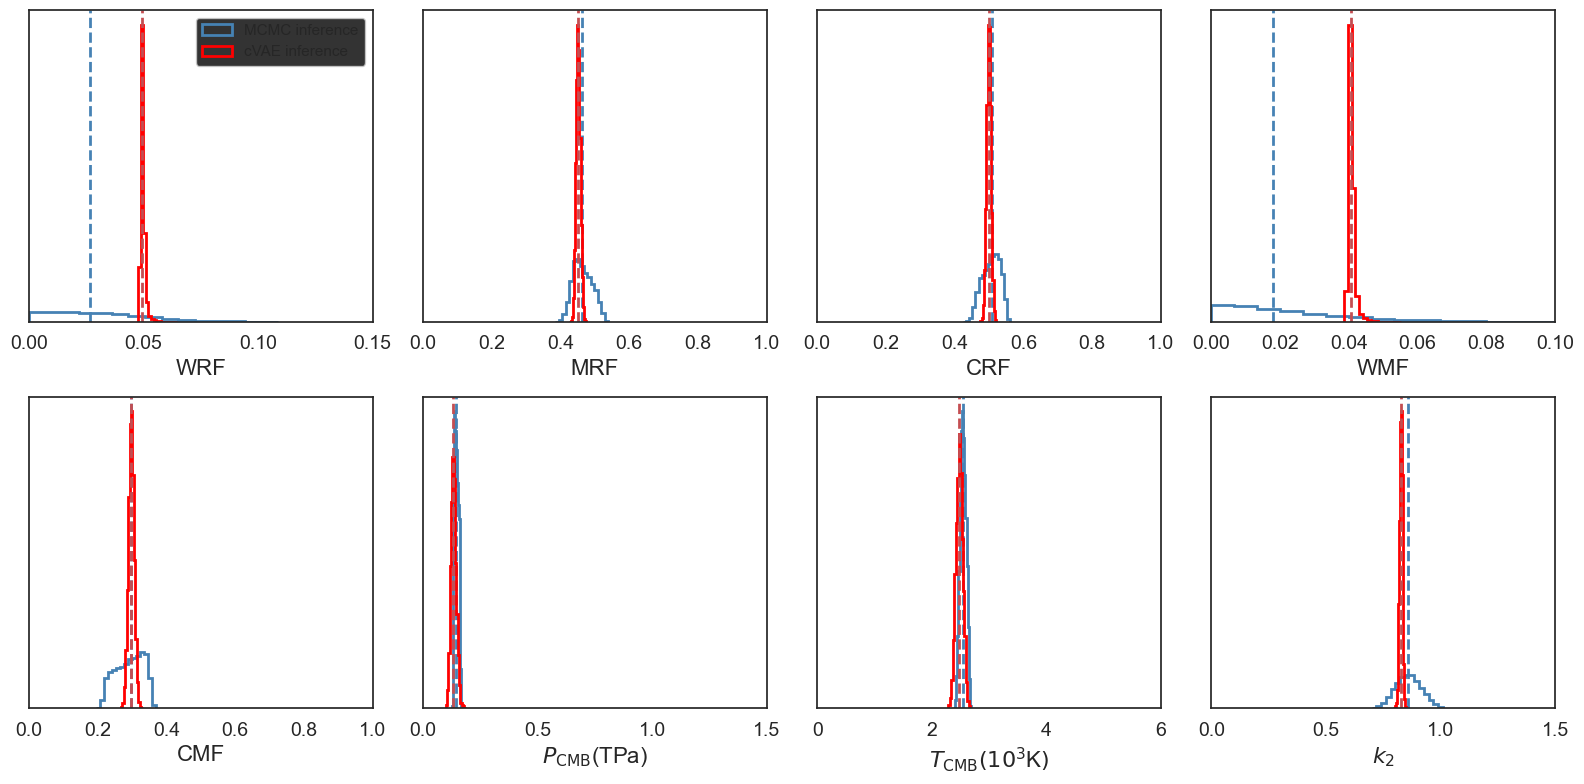

In [6]:
plot(model_comparison_for_test['Earth']['cVAE'], x_labels, model_comparison_for_test['Earth']['MCMC'], 'cVAE')

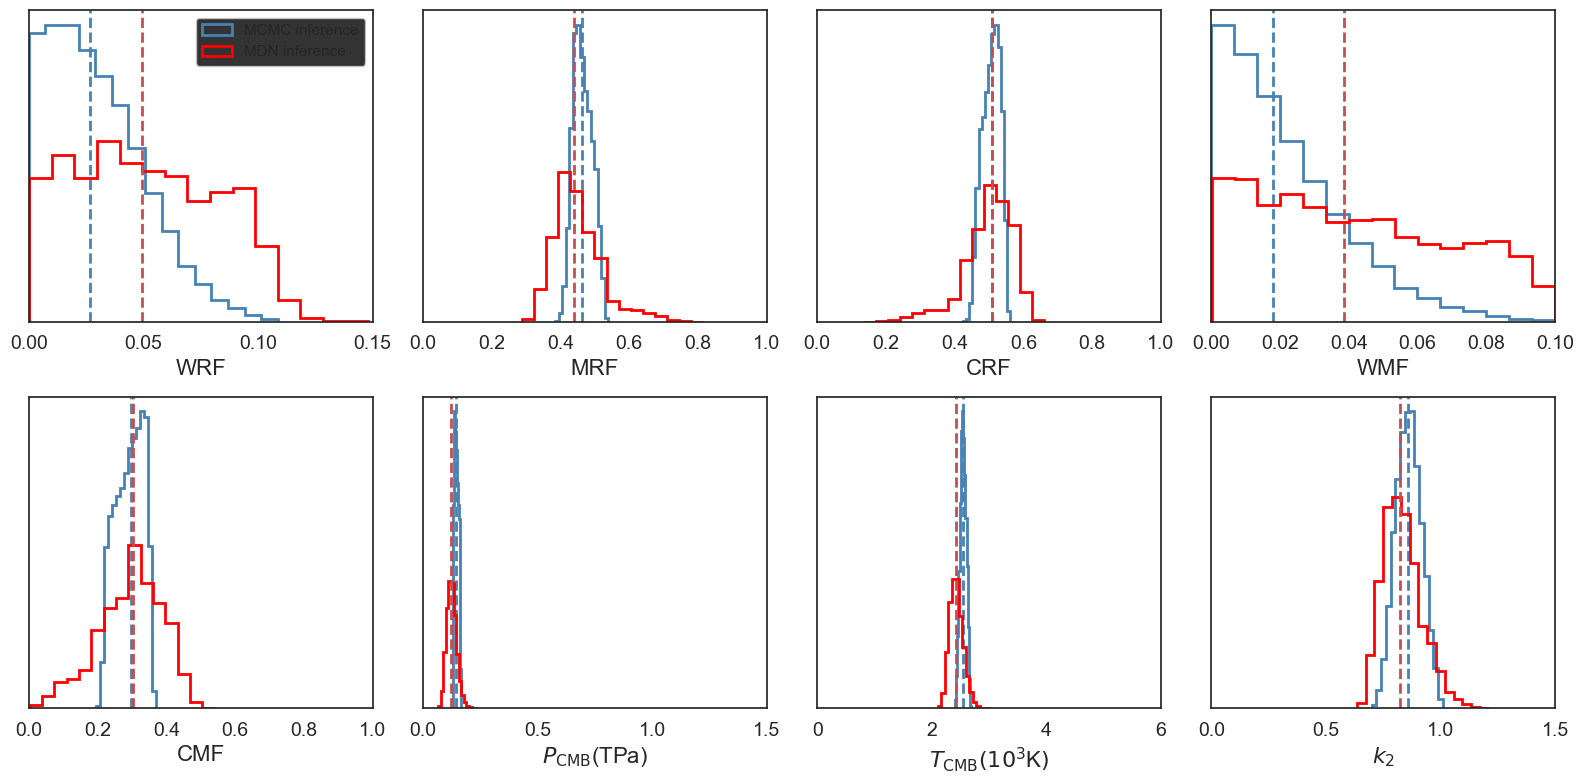

In [7]:
plot(model_comparison_for_test['Earth']['MDN'], x_labels, model_comparison_for_test['Earth']['MCMC'], 'MDN')

In [8]:
dict_base_path = os.path.join(base_path, 'Charts', 'Ridge')

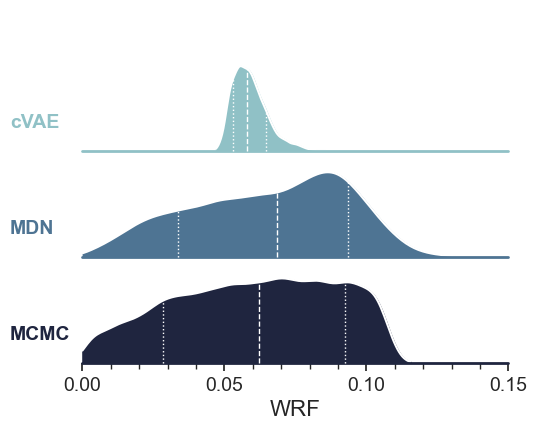

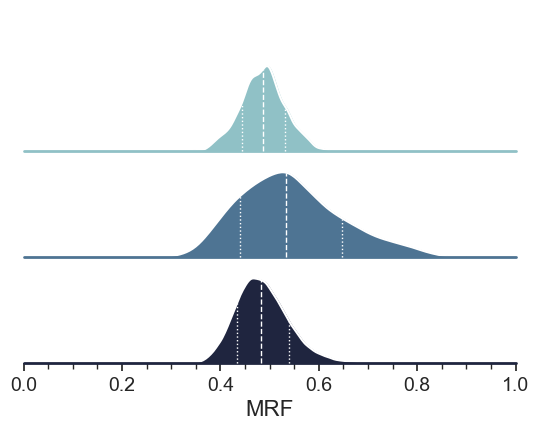

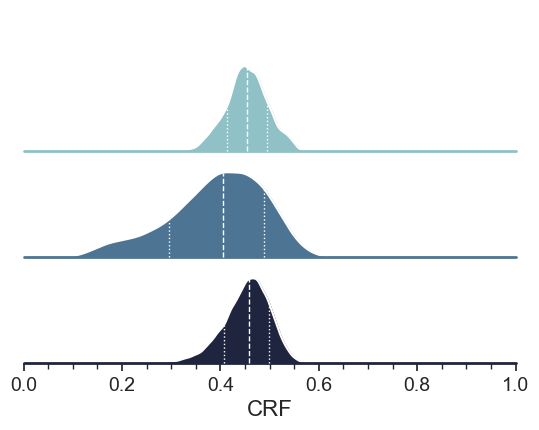

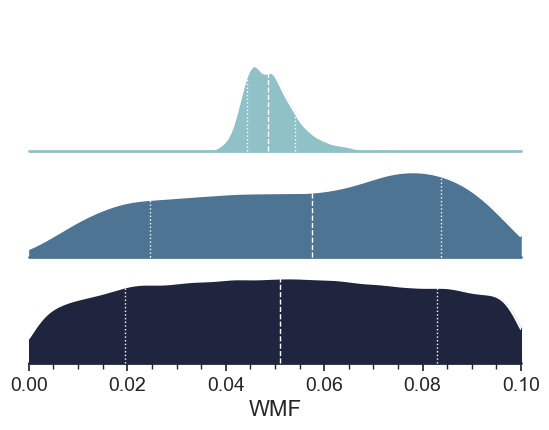

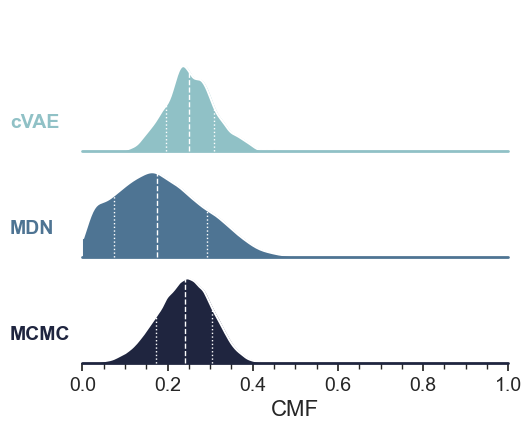

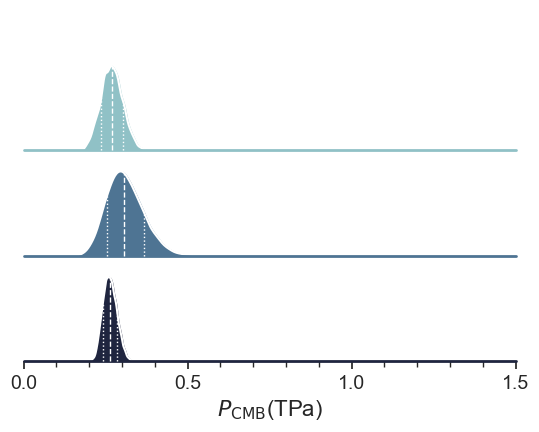

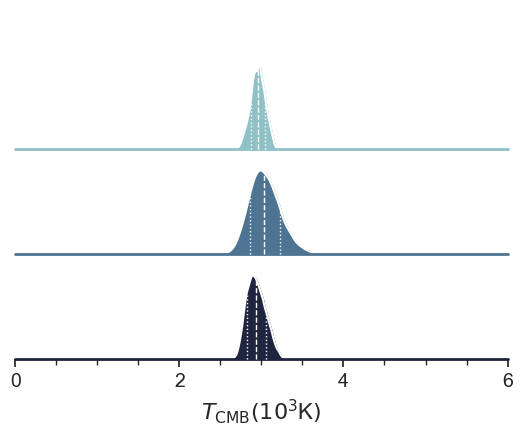

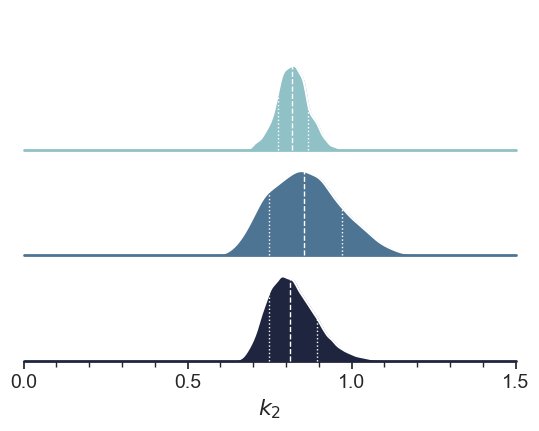

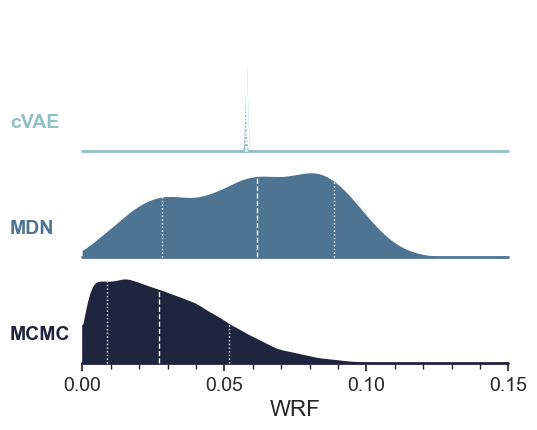

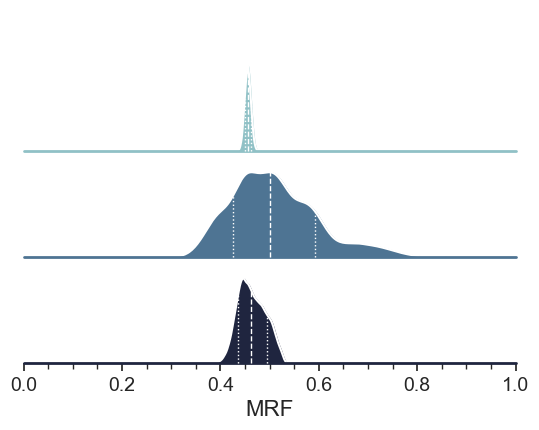

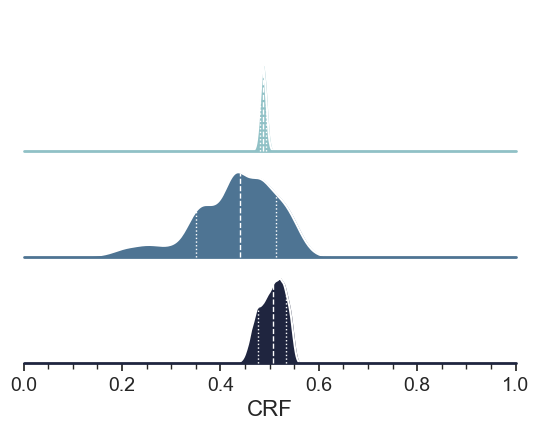

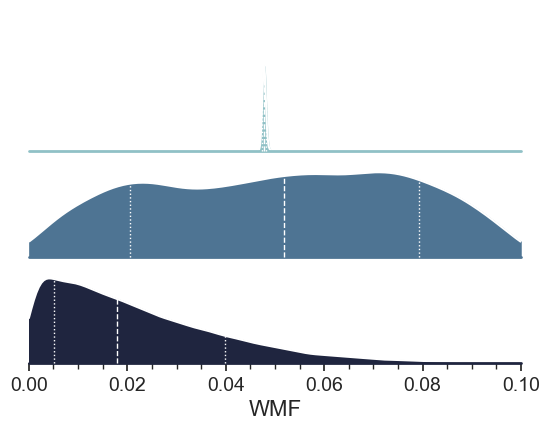

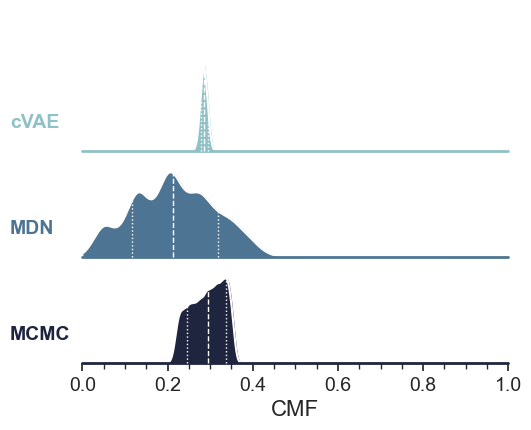

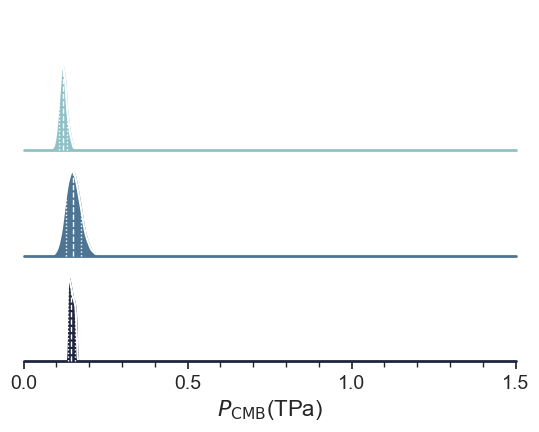

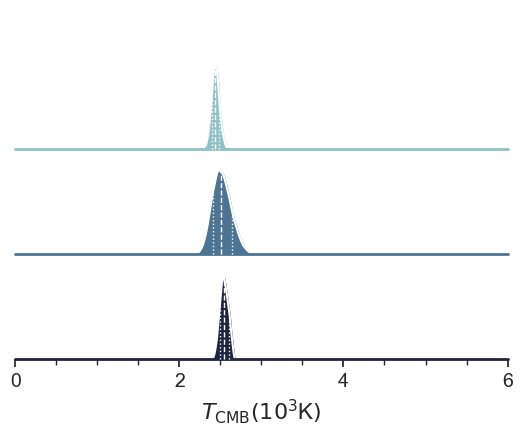

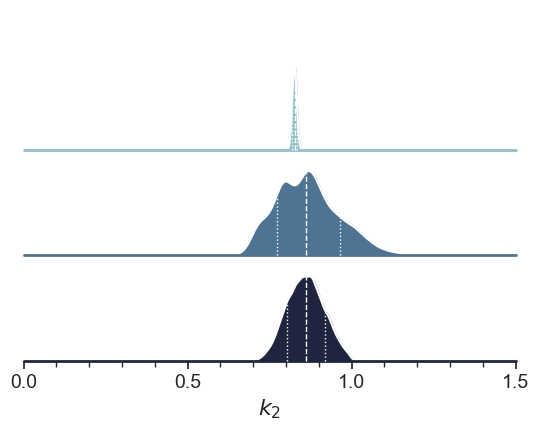

In [8]:
# p_n = 'Kepler78b'
# tmp = None
def scaled_kde(x, color, label, bw_adjust=1.2, height=0.6, gridsize=200, **kwargs):
    """
    在当前 Axes 上画一个按自身 max(y) 缩放到 height 的 KDE 填充和白色轮廓。
    - x:        当前分组的数据数组
    - color:    该分组对应的颜色
    - bw_adjust:带宽缩放因子
    - height:   最终峰值要占子图高度的比例 (0~1)
    - gridsize: 计算 KDE 的采样点数
    """
    
    ax = plt.gca()
    # 1. 计算原始 KDE
    kde = gaussian_kde(x)
    kde.set_bandwidth(kde.factor * bw_adjust)
    x_grid = np.linspace(x.min(), x.max(), gridsize)
    y = kde(x_grid)
    # 2. 缩放：让 max(y) → height
    y = y / y.max() * height
    
    # 3. 填充和描边
    ax.fill_between(x_grid, y, color=color, alpha=1, clip_on=(0, None), **kwargs)
    ax.plot(x_grid, y, color="w", linewidth=1.5, clip_on=(0, None))
    
    # if label != 'cVAE':
    ax.set_ylim(0, 1)   
    
def label(x, color, label):
        ax = plt.gca()
        ax.text(-0.17, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes, fontsize=14)
        
def locator(x, color, label):
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.MultipleLocator(x_locator[idx]))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(xminorlocators[idx]))

def draw_median(x, color, label, **kwargs):
    ax = plt.gca()
    p16, p84 = np.percentile(x, [16, 84])
    # 2. 用 gaussian_kde 重新估计密度，并套用相同的 bw_adjust
    med = np.median(x)
    # 拿到白色轮廓线（最后一条 Line2D）
    outline = ax.lines[-1]
    xd, yd = outline.get_xdata(), outline.get_ydata()
    # 在 med 处插值出对应的密度高度
    y_med = np.interp(med, xd, yd)
    y16 = np.interp(p16, xd, yd)
    y84 = np.interp(p84, xd, yd)
    # 画一条从 y=0 到 y_med 的白色中值线
    ax.vlines(med, 0, y_med,
              color='w', linewidth=1.0, linestyle='--',
              zorder=5, clip_on=False)
    ax.vlines(p16, 0, y16, color='w', linestyle=':', linewidth=1.0, zorder=5, clip_on=False)
    ax.vlines(p84, 0, y84, color='w', linestyle=':', linewidth=1.0, zorder=5, clip_on=False)

    
for p_n in planet_name:
        
    for idx, o in enumerate(x_labels):
    
        df = model_comparison[p_n].loc[:, [o, 'model']].copy()
        df[o] = df[o].astype(float)
        pal = sns.cubehelix_palette(3, rot=-.25, light=.7)  # 10 色渐变调色盘
        g = sns.FacetGrid(df, row="model", hue="model",
                          aspect=15, palette=pal, sharey=True)
        
        # g.map(sns.kdeplot, o,
        #       bw_adjust=1.2, clip_on=(0, None),
        #       fill=True, alpha=1, linewidth=1.5)
        # 
        # g.map(sns.kdeplot, o, clip_on=(0, None),
        #       color="w", lw=2, bw_adjust=1.2)
        g.map(scaled_kde, o)
        g.map(draw_median, o)
        if idx == 0 or idx == 4:
            g.map(label, o)
        # g.map(locator, o)
        g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)
        # global_max = max(ax.get_ylim()[1] for ax in g.axes.flat)
        # target_max = global_max / 0.8
        
        g.figure.subplots_adjust(hspace=-.25)
        
        g.set_titles("")
        g.set(yticks=[], ylabel="")
        g.set_xlabels(fontsize=16)
        g.despine(bottom=True, left=True)
        g.fig.set_size_inches(5, 4)
        
        for ax in g.axes.flat:
            ax.xaxis.set_major_locator(plt.MultipleLocator(x_locator[idx]))
            ax.xaxis.set_minor_locator(AutoMinorLocator())
            ax.set_xlim(0, x_max[idx])
            # ax.set_ylim(0, target_max)
            if ax == g.axes[-1]:  # 最后一个子图
                
                ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='out', labelsize=14)
            else:
                ax.set_xticks([]) 
        
        if not os.path.exists(os.path.join(dict_base_path, p_n)):
            os.mkdir(os.path.join(dict_base_path, p_n))
        
        if o == '$P_{\mathrm{CMB}}$(TPa)':
            o = 'CPS'
        
        elif o == '$T_{\mathrm{CMB}}(10^{3}$K$)$':
            o = 'CTP'
        
        
        # g.fig.savefig(os.path.join(dict_base_path, p_n, '{}_ridge_{}.pdf'.format(p_n, o)),
        #               dpi=100,
        #               bbox_inches="tight",
        #               transparent=False)


In [9]:
comparison_for_json = model_comparison.copy()
for k, v in comparison_for_json.items():
    comparison_for_json[k] = comparison_for_json[k].to_dict()

# json.dump(comparison_for_json, open(os.path.join(dict_base_path, 'model_comparison.json'), 'w+'))

In [10]:
comparison_all = []
for p_n in planet_name:
    df_k_p = model_comparison[p_n]
    df_k_p = df_k_p[df_k_p['model']=='MCMC']
    df_k_p = df_k_p.iloc[:, :-1].astype(float)
    # 从MCMC结果中获取84%和16%的位置误差
    q16 = df_k_p.quantile(0.16)
    q84 = df_k_p.quantile(0.84)
    
    # 计算CVAE结果的中位数和位置误差
    df_cvae = model_comparison[p_n][model_comparison[p_n]['model']=='cVAE']
    df_cvae = df_cvae.iloc[:, :-1].astype(float)
    median = np.median(df_cvae, axis=0)
    lower_err = median - np.percentile(df_cvae, q=16, axis=0)
    upper_err = np.percentile(df_cvae, q=84, axis=0) - median
    
    # 计算MCMC结果的中位数和位置误差
    mcmc_median = df_k_p.median()
    mcmc_lower_err = mcmc_median - q16
    mcmc_upper_err = q84 - mcmc_median
    
    # 計算MDN結果的中位數和位置誤差
    df_mdn = model_comparison[p_n][model_comparison[p_n]['model']=='MDN']
    df_mdn = df_mdn.iloc[:, :-1].astype(float)
    median_mdn = np.median(df_mdn, axis=0)
    lower_err_mdn = median - np.percentile(df_mdn, q=16, axis=0)
    upper_err_mdn = np.percentile(df_mdn, q=84, axis=0) - median
    
    # 将所有结果存储在一个DataFrame中
    results = {
        "Output Parameter": output_parameters,
        "MCMC Median": mcmc_median,
        "cVAE Median": median.tolist(),
        "MDN Median": median_mdn.tolist(),
        "MCMC Lower Error": mcmc_lower_err,
        "MCMC Upper Error": mcmc_upper_err,
        "cVAE Lower Error": lower_err,
        "cVAE Upper Error": upper_err,
        "MDN Lower Error": lower_err_mdn,
        "MDN Upper Error": upper_err_mdn
    }
    df_results = pd.DataFrame(results)
    
    mcmc_uncertainty = [p_n, 'MCMC']
    cvae_uncertainty = [p_n, 'cVAE']
    mdn_uncertainty = [p_n, 'MDN']
    for idx, o in enumerate(output_parameters):
        # curr_output_df = df_results[df_results['Output Parameter'] == o].copy()
        
        tmp_mcmc = '\\({a}_{{-{b}}}^{{+{c}}}\\)'.format(a=round(df_results[df_results['Output Parameter'] == o]['MCMC Median'].item(), 4), b=round(df_results[df_results['Output Parameter'] == o]['MCMC Lower Error'].item(), 4), c=round(df_results[df_results['Output Parameter'] == o]['MCMC Upper Error'].item(), 4))
        
        tmp_cvae = '\\({a}_{{-{b}}}^{{+{c}}}\\)'.format(a=round(df_results[df_results['Output Parameter'] == o]['cVAE Median'].item(), 4), b=round(df_results[df_results['Output Parameter'] == o]['cVAE Lower Error'].item(), 4), c=round(df_results[df_results['Output Parameter'] == o]['cVAE Upper Error'].item(), 4))
        
        tmp_mdn = '\\({a}_{{-{b}}}^{{+{c}}}\\)'.format(a=round(df_results[df_results['Output Parameter'] == o]['MDN Median'].item(), 4), b=round(df_results[df_results['Output Parameter'] == o]['MDN Lower Error'].item(), 4), c=round(df_results[df_results['Output Parameter'] == o]['MDN Upper Error'].item(), 4))
        
        mcmc_uncertainty.append(tmp_mcmc)
        cvae_uncertainty.append(tmp_cvae)
        mdn_uncertainty.append(tmp_mdn)
        
    comparison_all.append([mcmc_uncertainty, cvae_uncertainty, mdn_uncertainty])
    # df_results['MCMC Uncertainty'] = mcmc_uncertainty
    # df_results['cVAE Uncertainty'] = cvae_uncertainty
    # df_results['MDN Uncertainty'] = mdn_uncertainty
    # print('-' * 20)
    # print(p_n)
    # print(df_results.loc[:, ['Output Parameter', 'MCMC Uncertainty', 'cVAE Uncertainty', 'MDN Uncertainty']].to_latex(index=False, caption='Model Performance', label='tab:example', longtable=False))

In [11]:
comparison_df = pd.DataFrame(np.vstack(comparison_all), columns=['Planet', 'Model'] + x_labels)
# comparison_dict = comparison_dict.fromkeys(x_labels)

In [ ]:
print(comparison_df.to_latex(index=False, float_format="%.4f", caption='Model Performance', label='tab:example', longtable=False))